In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
df = pd.read_csv("training_accuracy.csv")

total_windows = len(df)
epochs = df['epoch'].max() + 1
final_acc = df['running_accuracy'].iloc[-1]
final_f1 = df['running_f1'].iloc[-1]

In [9]:
print(f"Processed windows: {total_windows}")
print(f"Completed epochs: {epochs}")
print(f"Final accumulated training accuracy: {final_acc * 100:.2f}%")
print(f"Final accumulated Macro F1-score: {final_f1:.4f}")
print("\n Classification Report:")
print(classification_report(df['label'], df['pred'], target_names=["Neutral", "Dorsi", "Plantar"]))

Processed windows: 28720
Completed epochs: 8
Final accumulated training accuracy: 45.85%
Final accumulated Macro F1-score: 0.3883

 Classification Report:
              precision    recall  f1-score   support

     Neutral       0.42      0.52      0.46     10280
       Dorsi       0.47      0.63      0.54     11088
     Plantar       0.79      0.08      0.15      7352

    accuracy                           0.45     28720
   macro avg       0.56      0.41      0.38     28720
weighted avg       0.53      0.45      0.41     28720



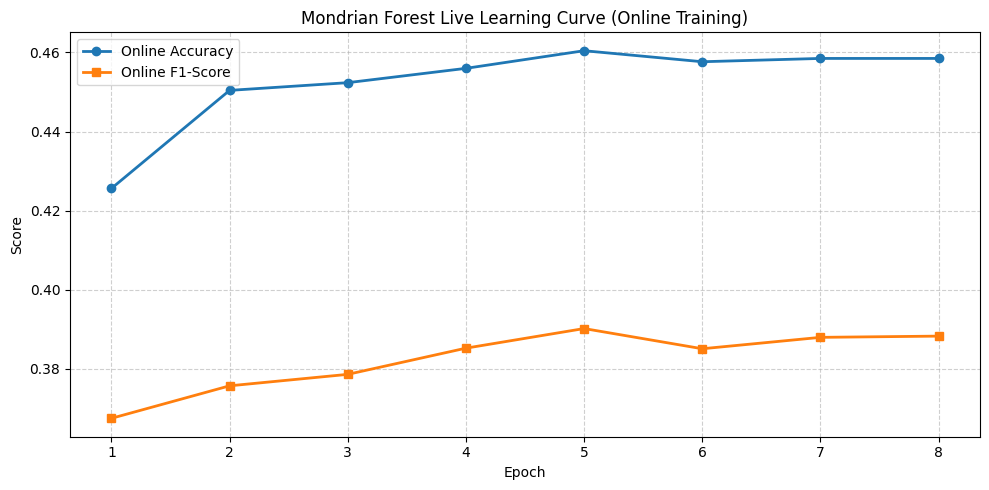

In [10]:
epoch_metrics = df.groupby('epoch').last().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(epoch_metrics['epoch'] + 1, epoch_metrics['running_accuracy'] , label='Online Accuracy', marker='o', linewidth=2)
plt.plot(epoch_metrics['epoch'] + 1, epoch_metrics['running_f1'] , label='Online F1-Score', marker='s', linewidth=2)
plt.title('Mondrian Forest Live Learning Curve (Online Training)')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

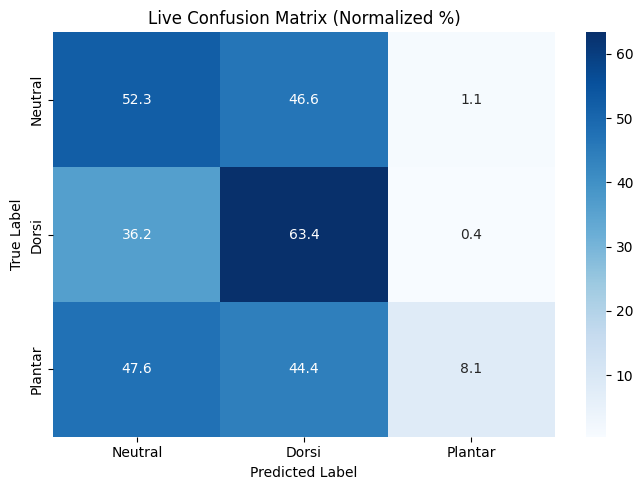

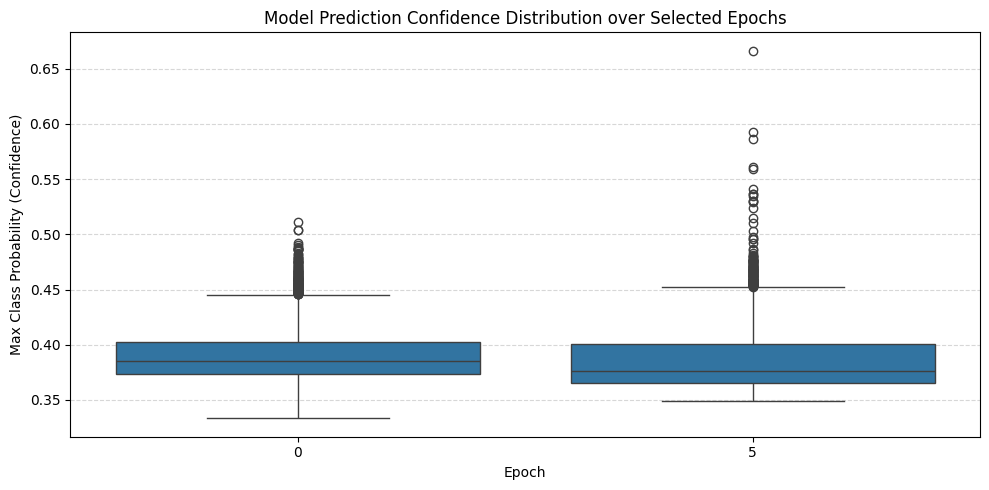

In [11]:
cm = confusion_matrix(df['label'], df['pred'])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(7, 5))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=["Neutral", "Dorsi", "Plantar"], 
            yticklabels=["Neutral", "Dorsi", "Plantar"])
plt.title('Live Confusion Matrix (Normalized %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='epoch', y='confidence', data=df[df['epoch'] % 5 == 0])
plt.title('Model Prediction Confidence Distribution over Selected Epochs')
plt.xlabel('Epoch')
plt.ylabel('Max Class Probability (Confidence)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "./dataset_rats_50w"
CLASS_NAMES = {0: "Dorsi (< -2°)", 1: "Plantar (> 2°)", 2: "Neutral (between -2° and 2°)"}


global_counts = {0: 0, 1: 0, 2: 0}




for filename in sorted(os.listdir(DATA_DIR)):
    if filename.endswith(".npz"):
        path = os.path.join(DATA_DIR, filename)

        data = np.load(path)
        angles = data["a"]
        

        labels = np.full(len(angles), 2, dtype=np.int64)  # Default: Neutral
        labels[angles > 2.0] = 1   # Plantar
        labels[angles < -2.0] = 0  # Dorsi
        

        unique, counts = np.unique(labels, return_counts=True)
        rat_counts = dict(zip(unique, counts))
        

        for c in (0, 1, 2):
            rat_counts[c] = rat_counts.get(c, 0)
            global_counts[c] += rat_counts[c] 
            
        total_rat_samples = sum(rat_counts.values())
        

        print(f"\nFil: {filename} (Total samples: {total_rat_samples})")
        for c_id, name in CLASS_NAMES.items():
            count = rat_counts[c_id]
            pct = (count / total_rat_samples) * 100 if total_rat_samples > 0 else 0
            print(f"  {name:<30}: {count:>6} samples ({pct:>5.2f}%)")

print("\n" + "="*50)
print("=== sum global class balance ===")
print("="*50)

total_global_samples = sum(global_counts.values())
for c_id, name in CLASS_NAMES.items():
    count = global_counts[c_id]
    pct = (count / total_global_samples) * 100 if total_global_samples > 0 else 0
    print(f"{name:<32}: {count:>7} samples ({pct:>5.2f}%)")
print(f"total sample count : {total_global_samples}")


Fil: rat10.npz (Total samples: 6536)
  Dorsi (< -2°)                 :   2100 samples (32.13%)
  Plantar (> 2°)                :   2411 samples (36.89%)
  Neutral (between -2° and 2°)  :   2025 samples (30.98%)

Fil: rat4.npz (Total samples: 7300)
  Dorsi (< -2°)                 :   2388 samples (32.71%)
  Plantar (> 2°)                :   2525 samples (34.59%)
  Neutral (between -2° and 2°)  :   2387 samples (32.70%)

Fil: rat5.npz (Total samples: 6748)
  Dorsi (< -2°)                 :   2310 samples (34.23%)
  Plantar (> 2°)                :   2501 samples (37.06%)
  Neutral (between -2° and 2°)  :   1937 samples (28.70%)

Fil: rat6.npz (Total samples: 6684)
  Dorsi (< -2°)                 :   2378 samples (35.58%)
  Plantar (> 2°)                :   2479 samples (37.09%)
  Neutral (between -2° and 2°)  :   1827 samples (27.33%)

Fil: rat7.npz (Total samples: 7233)
  Dorsi (< -2°)                 :   2336 samples (32.30%)
  Plantar (> 2°)                :   2677 samples (37.01%)
  